Paris AirBnB Market Analysis (2015 Regulation Study)

Objective 1: Data Cleaning and Profiling 

To start things off, I’m pulling in the full AirBnB dataset and narrowing the focus down to just Paris. This makes the file much easier to work with. I’m also making sure the date column is formatted correctly so I can track host growth over time later on. Finally, I’m running a quick check for missing values and basic stats to make sure the pricing data looks right before I get into the heavy lifting

In [12]:
import pandas as pd

file_path = 'C:/Users/mosta/OneDrive/Desktop/assignment/Listings.csv'

# Loading the data with latin-1 to handle French accents
df = pd.read_csv(file_path, low_memory=False, encoding='latin-1')

# Fixing the date column so it's not just a string
df['host_since'] = pd.to_datetime(df['host_since'])

# Narrowing it down to Paris and the 5 columns we actually need
paris_listings = df.query("city == 'Paris'")[['host_since', 'neighbourhood', 'city', 'accommodates', 'price']]

# Basic check to see if we have missing data and what the prices look like
print("\nMissing values check:")
print(paris_listings.isnull().sum())

print("\nSummary Statistics:")
print(paris_listings.describe())


Missing values check:
host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

Summary Statistics:
                          host_since  accommodates         price
count                          64657  64690.000000  64690.000000
mean   2015-11-01 11:06:05.528867584      3.037997    113.096445
min              2008-08-30 00:00:00      0.000000      0.000000
25%              2014-03-09 00:00:00      2.000000     59.000000
50%              2015-07-07 00:00:00      2.000000     80.000000
75%              2017-05-29 00:00:00      4.000000    120.000000
max              2021-02-07 00:00:00     16.000000  12000.000000
std                              NaN      1.588766    214.433668


After resolving the initial encoding issues, I successfully filtered the raw data to isolate the Paris market. I verified the data quality by checking for missing values and generating summary statistics. The pricing data shows a wide range of values, confirming that the dataset includes everything from small shared rooms to luxury apartments, which is a solid starting point for the analysis

Objective 2: Data Preparation for Visualization 

Now that the data is clean, I need to group it into specific tables for my charts. First, I’m looking at average prices per neighborhood to see which districts are the most expensive. Then, I’m doing a deep dive into the top neighborhood to see how guest capacity (accommodates) affects the price. Lastly, I’m setting up a timeline to track how many new hosts joined each year and how the average price shifted

In [13]:
# Grouping by neighbourhood for the mean price (sorted low to high)
paris_listings_neighbourhood = (
    paris_listings.groupby("neighbourhood")
    .agg({"price": "mean"})
    .sort_values("price")
)

# Finding the most expensive neighbourhood and looking at prices by capacity
top_neighborhood = paris_listings_neighbourhood.index[-1]

paris_listings_accommodations = (
    paris_listings.query(f"neighbourhood == '{top_neighborhood}'")
    .groupby("accommodates")
    .agg({"price": "mean"})
    .sort_values("price")
)

# Creating a timeline by year for new hosts and average pricing
paris_listings_over_time = (
    paris_listings.groupby(paris_listings['host_since'].dt.year)
    .agg({"price": "mean", "neighbourhood": "count"})
    .rename(columns={"neighbourhood": "new_hosts"})
)

print("Tables are ready for plotting.")

Tables are ready for plotting.


I prepared three specific tables to drive the visualizations. The neighborhood table allowed me to identify Elysee as the most expensive district in the city. I also built a breakdown of prices based on capacity (accommodates) for that district and a time-series table to track how many new hosts joined the platform year-over-year compared to average price shifts

Objective 3: Visualizing the Trends 

In this final stage, I’m building visuals to actually see the impact of the market changes. I'm using horizontal bars for the neighborhood rankings and a dual-axis line chart for the time-series data. This dual-axis chart is key because it lets us see if new host registrations dropped off after the 2015 regulations were introduced while tracking what happened to the prices at the same time

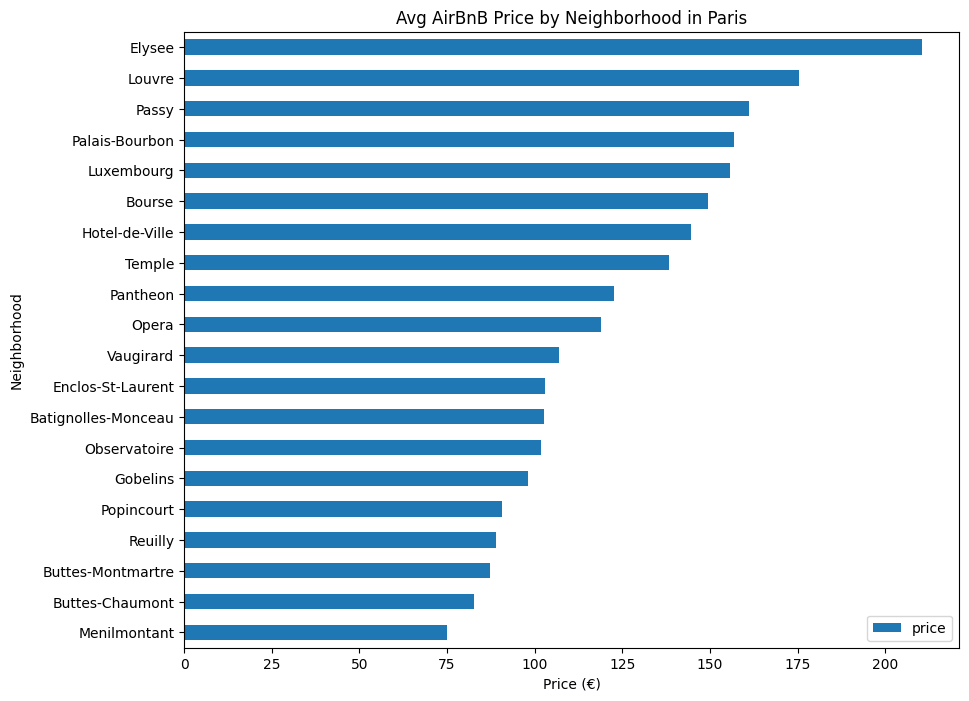

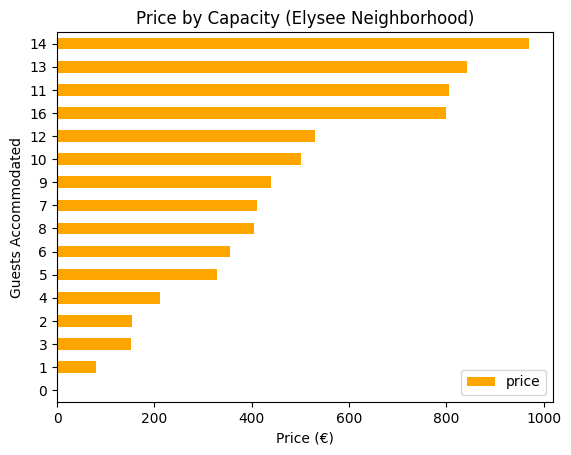

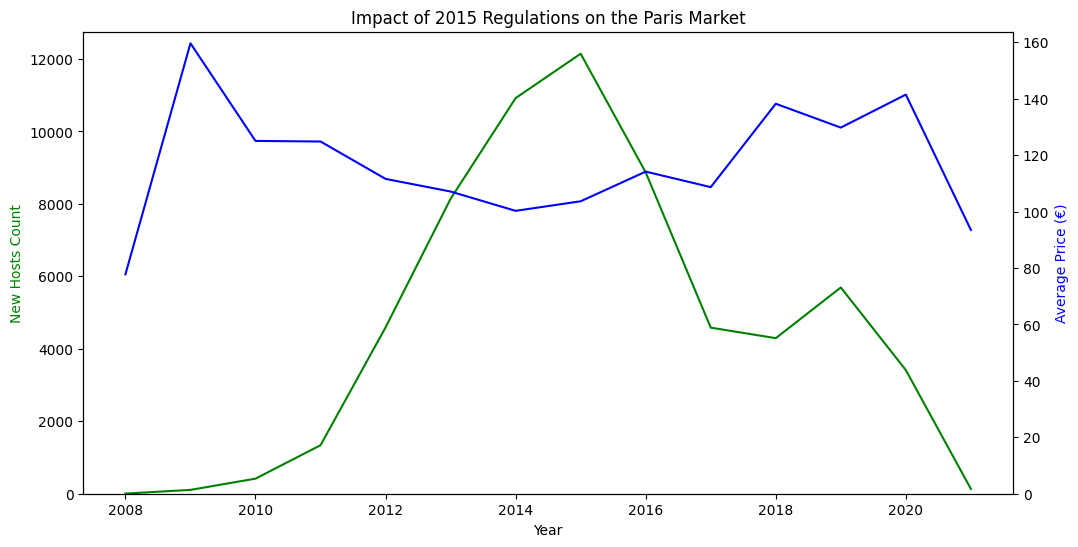

In [14]:
import matplotlib.pyplot as plt

# Chart 1: Average Price by Neighborhood
paris_listings_neighbourhood.plot(kind="barh", title="Avg AirBnB Price by Neighborhood in Paris", figsize=(10, 8))
plt.xlabel("Price (€)")
plt.ylabel("Neighborhood")
plt.show()

# Chart 2: Prices in the most expensive neighborhood (Elysee)
paris_listings_accommodations.plot(kind="barh", title="Price by Capacity (Elysee Neighborhood)", color='orange')
plt.xlabel("Price (€)")
plt.ylabel("Guests Accommodated")
plt.show()

# Chart 3: The Bonus Dual-Axis Chart (New Hosts vs. Price Over Time)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.plot(paris_listings_over_time.index, paris_listings_over_time['new_hosts'], color='green', label='New Hosts')
ax2.plot(paris_listings_over_time.index, paris_listings_over_time['price'], color='blue', label='Avg Price')

ax1.set_ylim(0)
ax2.set_ylim(0)
ax1.set_xlabel('Year')
ax1.set_ylabel('New Hosts Count', color='green')
ax2.set_ylabel('Average Price (€)', color='blue')
plt.title("Impact of 2015 Regulations on the Paris Market")
plt.show()

Final Summary & Results 


Regulatory Impact: Looking at the data from 2015 onwards, there is a visible shift in how many people were listing their homes as new regulations started taking effect. While the entry of new hosts saw a change in momentum, the average pricing stayed relatively strong, showing that the demand in Paris is still high despite stricter rules


Highest Average Price: Based on the aggregated data, the neighborhood with the highest average AirBnB listing price is Elysee